In [3]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import special

In [2]:
import scienceplots
plt.style.use("science")

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi']=120 #default is 72. 

In [14]:
prob_data = pd.read_csv("survival_probability_new.csv",sep=",")

x= prob_data["x (L/E)"]
P_ee= prob_data["P_ee"]
P_ee_err= prob_data["P_ee_err"]

prob_data.head()

,x (L/E),P_ee,P_ee_err_min,P_ee_err_max,P_ee_err
0,23.261848,0.588141,0.528376,0.649788,0.121412
1,28.602149,0.639309,0.585662,0.695780,0.110118
2,30.937424,0.687725,0.629842,0.748901,0.119059
3,32.780057,0.866976,0.795917,0.935682,0.139765
4,34.497508,0.722935,0.662700,0.783642,0.120941


In [17]:
P_err=(prob_data["P_ee_err_max"]-prob_data["P_ee"])*2

In [16]:
P_ee_err

0     0.121412
1     0.110118
2     0.119059
3     0.139765
4     0.120941
5     0.123294
6     0.096941
7     0.103530
8     0.089413
9     0.078588
10    0.081412
11    0.072941
12    0.098353
13    0.121883
14    0.143530
15    0.161412
16    0.184471
17    0.233883
18    0.417413
19    0.664472
Name: P_ee_err, dtype: float64

In [22]:
neutrino_flux = pd.read_csv("neutrino_flux.txt", sep="\s+")

In [25]:
L = neutrino_flux['Distance_km'].to_numpy()[:16] # Only Japan reactors
Phi = neutrino_flux['Flux_cm2_s'].to_numpy()[:16] # Only Japan reactors

L_avg = np.sum(L*Phi)/np.sum(Phi)

print(f"The flux-weighted average reactor baseline is L = {L_avg:.2f} km.")

The flux-weighted average reactor baseline is L = 188.43 km.


In [28]:
P_ee_weighted = np.zeros_like(P_ee)
Phi = neutrino_flux['Flux_cm2_s'].to_numpy() # Only Japan reactors


for i in range(len(P_ee)):
    P_ee_weighted[i]= np.sum(Phi*P_ee[i])/np.sum(Phi)

P_ee_weighted, P_ee

(array([0.58814102, 0.63930949, 0.68772513, 0.86697589, 0.72293548,
        0.73607193, 0.52991121, 0.60939577, 0.58440572, 0.47187665,
        0.51745749, 0.29338309, 0.51871532, 0.53322036, 0.55572167,
        0.61539078, 0.62516177, 0.61513546, 0.70201302, 0.26687864]),
 0     0.588141
 1     0.639309
 2     0.687725
 3     0.866976
 4     0.722935
 5     0.736072
 6     0.529911
 7     0.609396
 8     0.584406
 9     0.471877
 10    0.517457
 11    0.293383
 12    0.518715
 13    0.533220
 14    0.555722
 15    0.615391
 16    0.625162
 17    0.615135
 18    0.702013
 19    0.266879
 Name: P_ee, dtype: float64)

### Parameter reconstruction for Vacuum mass hypothesis

The neutrino oscillation probability ($P_{ee}$) for vacuum mass hypothesis is as follows:

Vacuum survival probability:

$$P_{ee} = 1 - \cos^{4}\theta_{13}\, \sin^{2} 2\theta_{12}\,\sin^{2}\left( 1.27\,\frac{\Delta m_{21}^{2}}{\rm{eV}^{2}} \frac{L/E_\nu}{\rm{m/MeV}}
\right) - \frac{1}{2}\sin^{2} 2\theta_{13}\ .$$


In [7]:
param_names = [r'$\Delta m^{2}_{21}$', r'$\theta_{12}$', r'$\theta_{13}$']

In [8]:
import scipy.stats

def my_prior_transform(cube): # The prior list for parameters
    params = cube.copy()

    # dm21 varies between [1-15]* 10^(-5) eV^2
    hi= 15
    lo= 1
    params[0] = (cube[0] * (hi - lo) + lo) #*10**(-5)

    # theta_12 varies within [0-1]
    params[1] = cube[1]

    # theta_13 varies within [0-1]
    params[2] = cube[2]

    return params

In [29]:
from numpy import log

def my_likelihood(params):
    dm21, theta12, theta13 = params
    
    # L = 180 #km
    # E = 5 #MeV
    
    # compute intensity at every x position according to the model
    P_ee_vac = 1 - np.cos(theta13)**4 * np.sin(2*theta12)**2 * np.sin(1.27*dm21*x* 10**(-2)) - 0.5 * np.sin(2*theta13)**2
    
    # compare model and data with gaussian likelihood:
    chi2 = np.sum(((P_ee_vac - P_ee_weighted)/P_ee_err)**2)
    like = -0.5 * chi2
    return like

In [30]:
import ultranest

sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform)

In [31]:
result = sampler.run(show_status=False, viz_callback=None)
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...
[ultranest] Explored until L=-4  
[ultranest] Likelihood function evaluations: 12021
[ultranest]   logZ = -9.985 +- 0.07775
[ultranest] Effective samples strategy satisfied (ESS = 1867.4, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.08, need <0.5)
[ultranest]   logZ error budget: single: 0.10 bs:0.08 tail:0.01 total:0.08 required:<0.50
[ultranest] done iterating.

logZ = -10.002 +- 0.149
  single instance: logZ = -10.002 +- 0.097
  bootstrapped   : logZ = -9.985 +- 0.149
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    $\Delta m^{2}_{21}$ : 1.00  │▁▁▁▁ ▁    ▁       ▁    ▁▁▁▁▁▂▅▇▇▅▃▁▁▁▁ │14.60     11.83 +- 0.82
    $\theta_{12}$       : 0.00  │▁▁  ▁▁▁▁▂▃▆▆▇▄▄▃▃▃▂▃▃▃▃▄▅▄▄▄▅▄▄▄▄▅▄▅▅▄▄│1.00      0.61 +- 0.24
    $\theta_{13}$       : 0.00  │▁  ▁  ▁▁ ▁▁   ▁▁   ▁▁

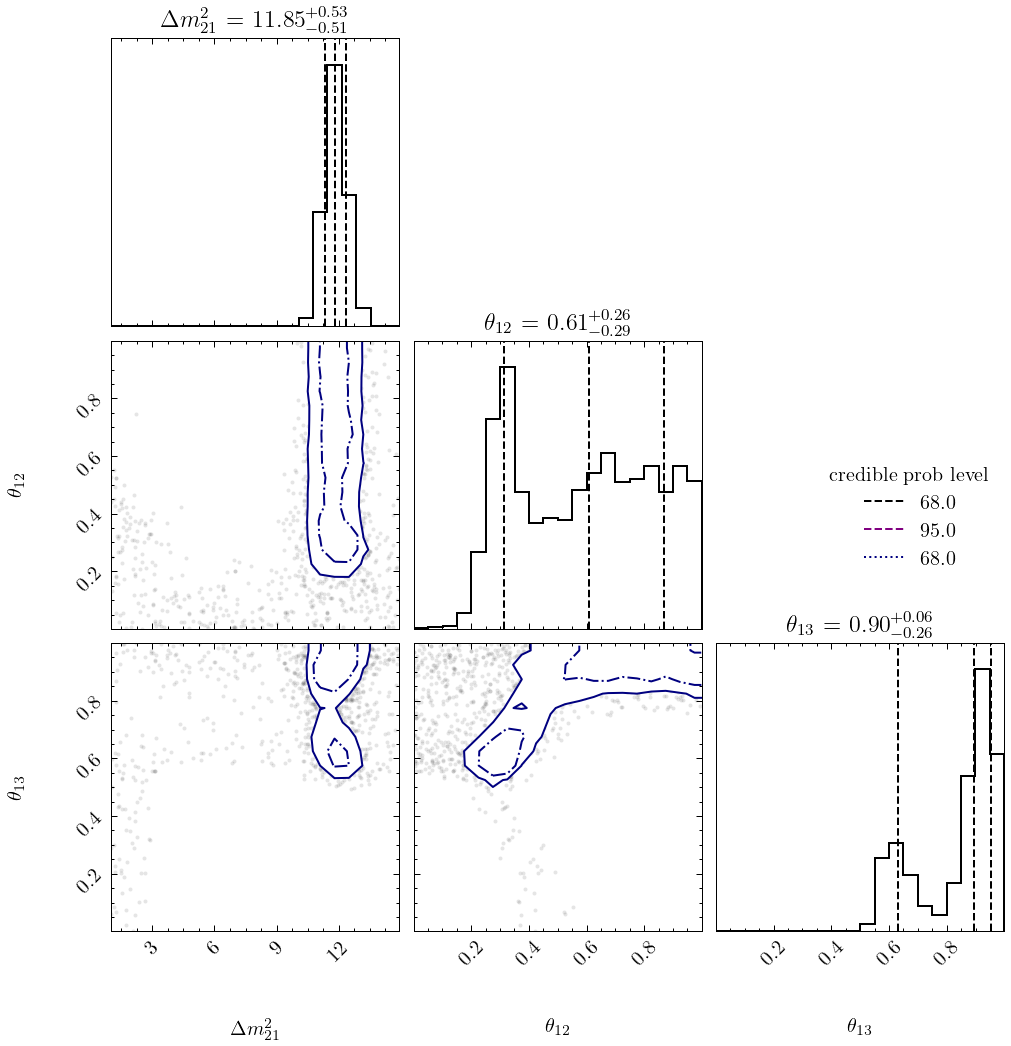

In [21]:
from ultranest.plot import cornerplot
fig= cornerplot(result,
                plot_datapoints=True, 
                levels=[0.68, 0.95],
                quantiles=[0.16, 0.5, 0.84],
                # show_titles=False,
                color='black',
                # plot_contour_labels=False
               );

# plt.tight_layout()
# plt.legend().remove()

plt.show()